# persistacnce

In [54]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai  import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [55]:
load_dotenv()

llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [56]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [57]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [5]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [19]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

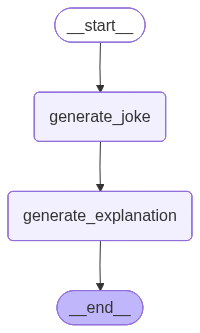

In [7]:
workflow

In [21]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1) 

{'topic': 'pizza',
 'joke': "Why did the pizza get a square box?\n\nBecause they didn't want to cut corners!",
 'explanation': 'This joke plays on the double meaning of the phrase "cut corners."\n\n1.  **Literal Meaning (in the context of pizza):**\n    *   A pizza is typically round.\n    *   A pizza box is typically square.\n    *   When you put a round pizza in a square box, there are empty spaces in the **corners** of the box. These corners are literally *not cut off* from the box itself. If you *were* to cut the corners off a square *pizza* to make it round, you\'d be literally cutting corners. The joke implies the *box* has corners that remain.\n\n2.  **Idiomatic Meaning:**\n    *   The phrase "to cut corners" means to do something in the easiest, quickest, or cheapest way, often by sacrificing quality, thoroughness, or safety. It means to take shortcuts.\n\n**The Punchline:**\nWhen the joke says "Because they didn\'t want to cut corners!", it\'s primarily using the **idiomatic m

In [22]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza get a square box?\n\nBecause they didn't want to cut corners!", 'explanation': 'This joke plays on the double meaning of the phrase "cut corners."\n\n1.  **Literal Meaning (in the context of pizza):**\n    *   A pizza is typically round.\n    *   A pizza box is typically square.\n    *   When you put a round pizza in a square box, there are empty spaces in the **corners** of the box. These corners are literally *not cut off* from the box itself. If you *were* to cut the corners off a square *pizza* to make it round, you\'d be literally cutting corners. The joke implies the *box* has corners that remain.\n\n2.  **Idiomatic Meaning:**\n    *   The phrase "to cut corners" means to do something in the easiest, quickest, or cheapest way, often by sacrificing quality, thoroughness, or safety. It means to take shortcuts.\n\n**The Punchline:**\nWhen the joke says "Because they didn\'t want to cut corners!", it\'s primarily usin

In [27]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza get a square box?\n\nBecause they didn't want to cut corners!", 'explanation': 'This joke plays on the double meaning of the phrase "cut corners."\n\n1.  **Literal Meaning (in the context of pizza):**\n    *   A pizza is typically round.\n    *   A pizza box is typically square.\n    *   When you put a round pizza in a square box, there are empty spaces in the **corners** of the box. These corners are literally *not cut off* from the box itself. If you *were* to cut the corners off a square *pizza* to make it round, you\'d be literally cutting corners. The joke implies the *box* has corners that remain.\n\n2.  **Idiomatic Meaning:**\n    *   The phrase "to cut corners" means to do something in the easiest, quickest, or cheapest way, often by sacrificing quality, thoroughness, or safety. It means to take shortcuts.\n\n**The Punchline:**\nWhen the joke says "Because they didn\'t want to cut corners!", it\'s primarily usi

In [28]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta break up with the sauce?\n\nBecause it felt like an **impasta**!',
 'explanation': 'This joke is a classic pun! Here\'s the breakdown:\n\n1.  **The Pun:** The joke hinges on the word "**impasta**."\n2.  **Sound-Alike:** "Impasta" sounds almost exactly like the word "**impostor**."\n3.  **Meaning of "Impostor":** An impostor is a person who pretends to be someone else, a fake, or a deceiver.\n4.  **The Joke\'s Implication:** So, when the pasta says it "felt like an impasta," it\'s humorously implying that it felt like an **impostor** in the relationship with the sauce. Perhaps it felt fake, not true to itself, or like it was pretending to be something it wasn\'t within that pairing.\n\nThe humor comes from the unexpected food-related twist on a common human emotion (feeling like a fake or not true to oneself) and the clever wordplay.'}

In [44]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!', 'explanation': 'This joke is a classic **pun** that plays on the similarity in sound between two words:\n\n1.  **Imposter:** An imposter is a person who pretends to be someone else in order to deceive others. People who are imposters might commit crimes like fraud or identity theft, and could certainly get arrested.\n2.  **Impasta:** This is a made-up word for the joke. It combines the prefix "im-" (which can mean "not" or "opposite of") with the word "pasta." The crucial part is that it sounds almost exactly like "imposter."\n\n**Here\'s why it\'s funny:**\n\n*   The setup ("Why did the pasta get arrested?") creates an absurd image of food committing a crime.\n*   The punchline ("Because it was an **impasta**!") works because it sounds like a legitimate reason for someone to get arrested (being an "imposter"), but it cleverly incorporates the word "pasta," making it a 

### Time Travel

In [36]:
#go to generate joke node
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f11d5a1-175b-65a9-8000-dd913a4fc32a"}})

StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f11d5a1-175b-65a9-8000-dd913a4fc32a'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-11T14:53:30.238506+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d5a1-1758-6e98-bfff-d3c16fe61f7b'}}, tasks=(PregelTask(id='3fe4fceb-160b-9a3d-b5e9-18d2ee7845da', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pasta break up with the sauce?\n\nBecause it felt like an **impasta**!'}),), interrupts=())

In [39]:
# run again ---> Imp None Value
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f11d5a1-175b-65a9-8000-dd913a4fc32a"}})

{'topic': 'pasta',
 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!',
 'explanation': 'This joke is a classic **pun** that plays on the similarity in sound between two words:\n\n1.  **Imposter:** An imposter is a person who pretends to be someone else in order to deceive others. People who are imposters might commit crimes like fraud or identity theft, and could certainly get arrested.\n2.  **Impasta:** This is a made-up word for the joke. It combines the prefix "im-" (which can mean "not" or "opposite of") with the word "pasta." The crucial part is that it sounds almost exactly like "imposter."\n\n**Here\'s why it\'s funny:**\n\n*   The setup ("Why did the pasta get arrested?") creates an absurd image of food committing a crime.\n*   The punchline ("Because it was an **impasta**!") works because it sounds like a legitimate reason for someone to get arrested (being an "imposter"), but it cleverly incorporates the word "pasta," making it a food-related twist o

In [40]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!', 'explanation': 'This joke is a classic **pun** that plays on the similarity in sound between two words:\n\n1.  **Imposter:** An imposter is a person who pretends to be someone else in order to deceive others. People who are imposters might commit crimes like fraud or identity theft, and could certainly get arrested.\n2.  **Impasta:** This is a made-up word for the joke. It combines the prefix "im-" (which can mean "not" or "opposite of") with the word "pasta." The crucial part is that it sounds almost exactly like "imposter."\n\n**Here\'s why it\'s funny:**\n\n*   The setup ("Why did the pasta get arrested?") creates an absurd image of food committing a crime.\n*   The punchline ("Because it was an **impasta**!") works because it sounds like a legitimate reason for someone to get arrested (being an "imposter"), but it cleverly incorporates the word "pasta," making it a 

In [45]:
for x in list(workflow.get_state_history(config2)):
    print(x.next)

()
('generate_explanation',)
()
('generate_explanation',)
('generate_joke',)
('__start__',)


## Update State

In [47]:
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f11d5a1-175b-65a9-8000-dd913a4fc32a"}})

StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f11d5a1-175b-65a9-8000-dd913a4fc32a'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-11T14:53:30.238506+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d5a1-1758-6e98-bfff-d3c16fe61f7b'}}, tasks=(PregelTask(id='3fe4fceb-160b-9a3d-b5e9-18d2ee7845da', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pasta break up with the sauce?\n\nBecause it felt like an **impasta**!'}),), interrupts=())

In [ ]:
# update the state at particular checkpoint
workflow.update_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f11d5a1-175b-65a9-8000-dd913a4fc32a", "checkpoint_ns": ""}}, {'topic':'tomato'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11d5b0-35f0-628a-8001-8bc6b307b394'}}

In [50]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'tomato'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d5b0-35f0-628a-8001-8bc6b307b394'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-03-11T15:00:16.098369+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f11d5a1-175b-65a9-8000-dd913a4fc32a'}}, tasks=(PregelTask(id='d98af01b-7e26-f4e8-9f0f-ecdf82afb426', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!', 'explanation': 'This joke is a classic **pun** that plays on the similarity in sound between two words:\n\n1.  **Imposter:** An imposter is a person who pretends to be someone else in order to deceive others. People who are imposters might commit crimes like fra

In [ ]:
# pass the checkpoint id of 
workflow.invoke(None, {"configurable": {"thread_id": "2", "checkpoint_id": "1f11d5b0-35f0-628a-8001-8bc6b307b394"}})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 30.43738069s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi

In [59]:
for x in list(workflow.get_state_history(config1)):
    print(x.next , "--" , x.values['topic'])

() -- pizza
('generate_explanation',) -- pizza
('generate_joke',) -- pizza


KeyError: 'topic'

# Fault Tolerance

In [20]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

True

In [21]:
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [22]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [23]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(10)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

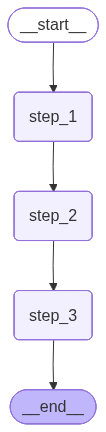

In [24]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [25]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [26]:
# 6. Re-run to show fault-tolerant resume || Pass None instead of initial_state
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [31]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d5da-ecca-6cbc-8003-002ba2b1e3c1'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-11T15:19:22.700921+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d5da-ecc5-6e91-8002-191c1efbe87c'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d5da-ecc5-6e91-8002-191c1efbe87c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-03-11T15:19:22.698920+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f11d5d9-dded-62d9-8001-c14adcd65b97'}}, tasks=(PregelTask(id='2dfadf54-6f17-b0cf-f697-4a6ebc657f9

In [32]:
import yt_dlp

playlist_url = "https://www.youtube.com/playlist?list=PLKnIA16_Rmva_oZ9F4ayUu9qcWgF7Fyc0"

ydl_opts = {
    "quiet": True,
    "extract_flat": True
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    result = ydl.extract_info(playlist_url, download=False)

links = []
for video in result["entries"]:
    links.append(f"https://www.youtube.com/watch?v={video['id']}")

for link in links:
    print(link)

https://www.youtube.com/watch?v=3_TN1i3MTEU
https://www.youtube.com/watch?v=Zmy439spZB4
https://www.youtube.com/watch?v=nQa31xdXbGk
https://www.youtube.com/watch?v=sBHeMcxupmE
https://www.youtube.com/watch?v=y-uPv3ltOTY
https://www.youtube.com/watch?v=tc2oOznpdE0
https://www.youtube.com/watch?v=GF7-ZzUausU
https://www.youtube.com/watch?v=o4ajsc-tSBc
